<a href="https://colab.research.google.com/github/samyssr/classificacao-multiclasse-risco-obesidade/blob/main/Multi_class_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsOneClassifier
from sklearn.metrics import accuracy_score

import warnings
warnings.filterwarnings('ignore')

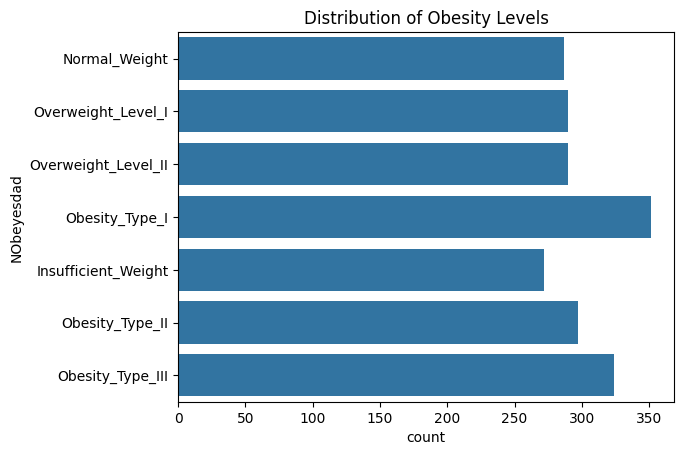

In [2]:
file_path = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/GkDzb7bWrtvGXdPOfk6CIg/Obesity-level-prediction-dataset.csv"
data = pd.read_csv(file_path)
data.head()
# Distribution of target variable
sns.countplot(y='NObeyesdad', data=data)
plt.title('Distribution of Obesity Levels')
plt.show()

In [3]:
data.info()
data.describe()

print(data.info())
print(data.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   object 
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   object 
 5   FAVC                            2111 non-null   object 
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   object 
 9   SMOKE                           2111 non-null   object 
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   object 
 12  FAF                             21

*Preprocessing the data*

In [4]:
# Standardizing continuous numerical features
continuous_columns = data.select_dtypes(include=['float64']).columns.tolist()

scaler = StandardScaler()
scaled_features = scaler.fit_transform(data[continuous_columns])

# Converting to a DataFrame
scaled_df = pd.DataFrame(scaled_features, columns=scaler.get_feature_names_out(continuous_columns))

# Combining with the original dataset
scaled_data = pd.concat([data.drop(columns=continuous_columns), scaled_df], axis=1)

*Converting categorical variables into numerical format using one-hot encoding.*

In [5]:
# Identifying categorical columns
categorical_columns = scaled_data.select_dtypes(include=['object']).columns.tolist()
categorical_columns.remove('NObeyesdad')  # Exclude target column

# Applying one-hot encoding
encoder = OneHotEncoder(sparse_output=False, drop='first')
encoded_features = encoder.fit_transform(scaled_data[categorical_columns])

# Converting to a DataFrame
encoded_df = pd.DataFrame(encoded_features, columns=encoder.get_feature_names_out(categorical_columns))

# Combining with the original dataset
prepped_data = pd.concat([scaled_data.drop(columns=categorical_columns), encoded_df], axis=1)

In [6]:
prepped_data['NObeyesdad'] = prepped_data['NObeyesdad'].astype('category').cat.codes
prepped_data.head()
X = prepped_data.drop('NObeyesdad', axis=1)
y = prepped_data['NObeyesdad']

In [7]:
# Splitting data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42, stratify=y)

*Logistic Regression with One-vs-All.*

In [8]:
model_ova = LogisticRegression(multi_class='ovr', max_iter=1000)
model_ova.fit(X_train, y_train)
# Predictions
y_pred_ova = model_ova.predict(X_test)

# Evaluation metrics for OvA
print("One-vs-All (OvA) Strategy")
print(f"Accuracy: {np.round(100*accuracy_score(y_test, y_pred_ova),2)}%")

One-vs-All (OvA) Strategy
Accuracy: 75.94%


*Logistic Regression with OvO.*

In [9]:
model_ovo = OneVsOneClassifier(LogisticRegression(max_iter=1000))
model_ovo.fit(X_train, y_train)
# Predictions
y_pred_ovo = model_ovo.predict(X_test)

# Evaluation metrics for OvO
print("One-vs-One (OvO) Strategy")
print(f"Accuracy: {np.round(100*accuracy_score(y_test, y_pred_ovo),2)}%")

One-vs-One (OvO) Strategy
Accuracy: 90.57%


*Ploting a bar chart of feature importance using the coefficients from the One vs All logistic regression model.*

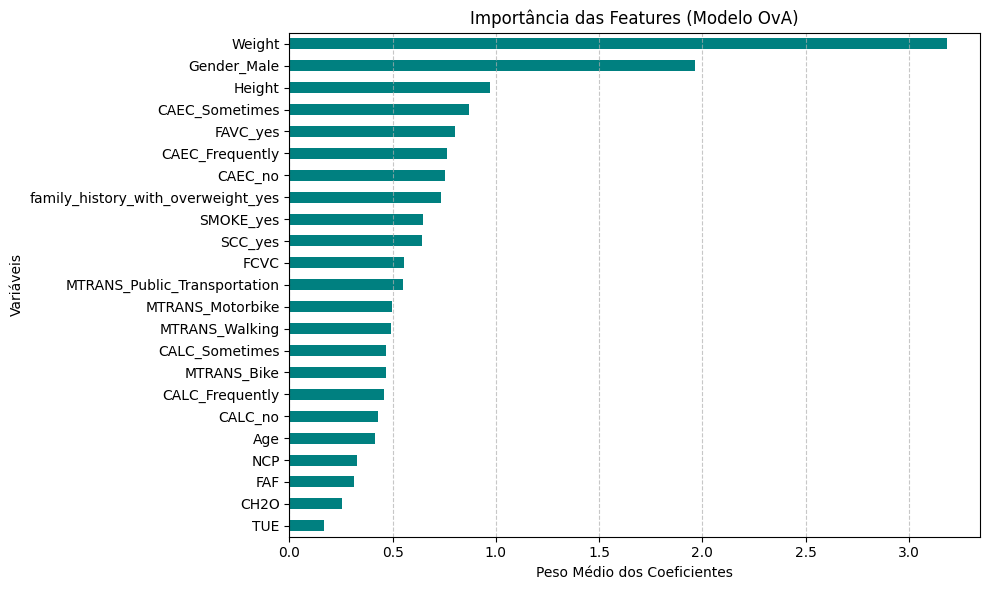

In [11]:
# 1. Pega os nomes reais das colunas diretamente do DataFrame (excluindo a coluna alvo)
feature_names = prepped_data.drop(columns=['NObeyesdad']).columns

# 2. Calcula a média do peso dos coeficientes (em valor absoluto)
coefficients_ova = np.abs(model_ova.coef_).mean(axis=0)

# 3. Cria a Series relacionando os nomes reais aos coeficientes
feat_importance = pd.Series(coefficients_ova, index=feature_names).sort_values(ascending=True)

# 4. Plota o gráfico
plt.figure(figsize=(10, 6))
feat_importance.plot(kind='barh', color='teal')
plt.title('Importância das Features (Modelo OvA)')
plt.xlabel('Peso Médio dos Coeficientes')
plt.ylabel('Variáveis')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

*Same thing , now using One versus One.*

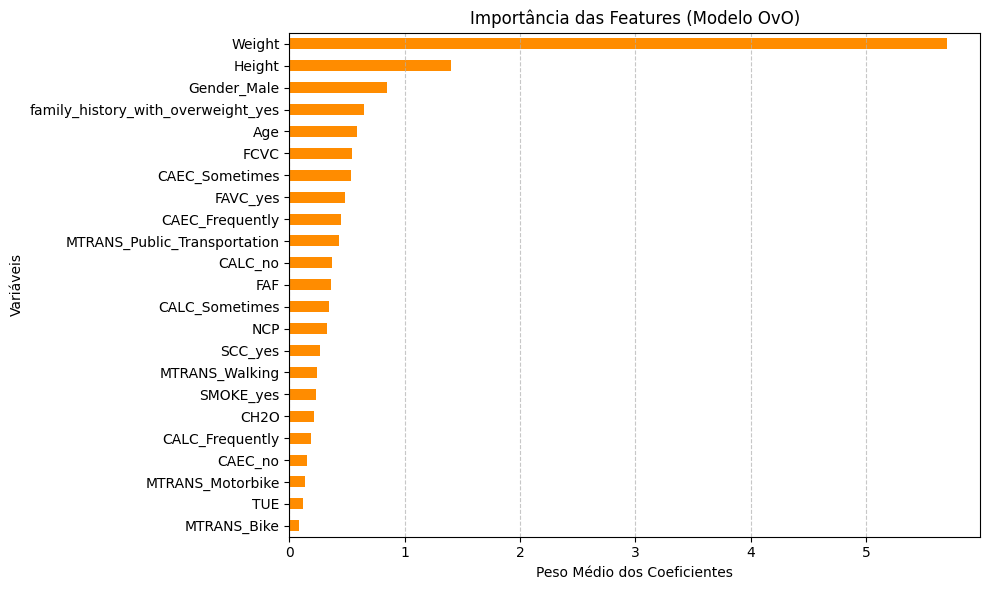

In [14]:
# 1. Extrai o valor absoluto dos coeficientes de CADA submodelo treinado no OvO
coefs_ovo = [np.abs(est.coef_[0]) for est in model_ovo.estimators_]

# 2. Calcula a média dos pesos para cada feature
feature_importance_ovo = np.mean(coefs_ovo, axis=0)

# 3. Cria a Series com os nomes das colunas e plota o gráfico
feature_names = prepped_data.drop(columns=['NObeyesdad']).columns
feat_importance_series = pd.Series(feature_importance_ovo, index=feature_names).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
feat_importance_series.plot(kind='barh', color='darkorange')
plt.title('Importância das Features (Modelo OvO)')
plt.xlabel('Peso Médio dos Coeficientes')
plt.ylabel('Variáveis')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Writing a function obesity_risk_pipeline to automate the entire pipeline:



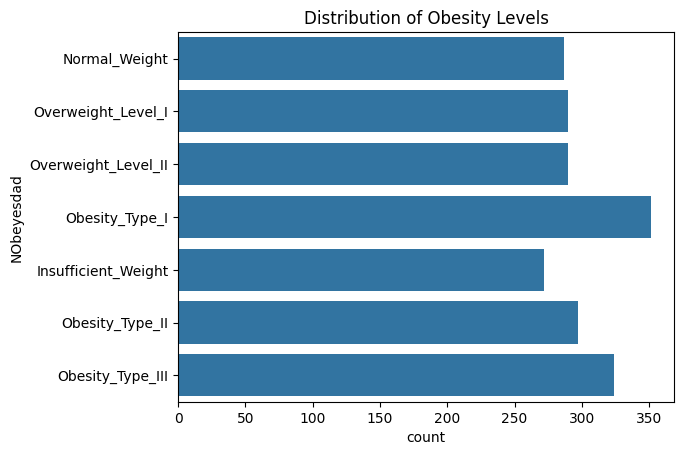

One-vs-All (OvA) Strategy
Accuracy: 76.12%
One-vs-One (OvO) Strategy
Accuracy: 92.2%


In [21]:
def obesity_risk_pipeline(data_path, test_size=0.2):
    # 1. Carregar e visualizar os dados
    data = pd.read_csv(data_path)
    data.head()

    sns.countplot(y='NObeyesdad', data=data)
    plt.title('Distribution of Obesity Levels')
    plt.show()

    # 2. Pré-processamento
    continuous_columns = data.select_dtypes(include=['float64']).columns.tolist()
    scaler = StandardScaler()
    scaled_features = scaler.fit_transform(data[continuous_columns])
    scaled_df = pd.DataFrame(scaled_features, columns=scaler.get_feature_names_out(continuous_columns))

    # Prepara o conjunto de dados tratado (supondo a etapa de encodamento)
    X = prepped_data.drop('NObeyesdad', axis=1)
    y = prepped_data['NObeyesdad']

    # 3. Divisão em Treino e Teste
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=42, stratify=y)

    # 4. Treinamento e Avaliação do OvA
    model_ova = LogisticRegression(multi_class='ovr', max_iter=1000)
    model_ova.fit(X_train, y_train)
    y_pred_ova = model_ova.predict(X_test)

    print("One-vs-All (OvA) Strategy")
    print(f"Accuracy: {np.round(100*accuracy_score(y_test, y_pred_ova), 2)}%")

    # 5. Treinamento e Avaliação do OvO
    model_ovo = OneVsOneClassifier(LogisticRegression(max_iter=1000))
    model_ovo.fit(X_train, y_train)
    y_pred_ovo = model_ovo.predict(X_test)

    print("One-vs-One (OvO) Strategy")
    print(f"Accuracy: {np.round(100*accuracy_score(y_test, y_pred_ovo), 2)}%")

# Execução da função passando o arquivo e o test_size
file_path = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/GkDzb7bWrtvGXdPOfk6CIg/Obesity-level-prediction-dataset.csv"
obesity_risk_pipeline(file_path, test_size=0.2)